# Relatividad y Gravitación
## Prof. Jorge I. Zuluaga

### Cuaderno de Clase: Aberración astronómica

In [2]:
!pip install -Uq pymcel rebound montu

## Aberración de la luz de las estrellas

In [3]:
import pymcel as pc
import montu as mn
import numpy as np
import matplotlib.pyplot as plt

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!
Running MontuPython version 0.10.0


1. ¿Qué voy a hacer?: experimento para estudiar el cambio de posición de las estrellas debido a la aberración. Poner a prueba la fórmula general de aberración, es decir la que relaciona $\hat n'$ con $\hat n$

2. ¿Qué necesito para hacerlo?: 
   - Calcular la velocidad de la estrella, que es la misma de la Tierra pero negativa.

   - Dirección en la que está la etrella respecto al SSB.

Velocidad de la Tierra:

In [54]:
tabla, jd, X = pc.consulta_horizons(
    id='399', 
    location='@0', 
    epochs='2025-03-24 15:40:00'
)
v_tierra = X[3:]
v_tierra

array([ 1.54361812e+03, -2.98426205e+04,  8.27267631e-01])

Saquemos ahora el beta de la estrella:

In [55]:
beta_vec = -v_tierra / pc.constantes.c
beta = np.linalg.norm(beta_vec)
beta_vec, beta

(array([-5.14895583e-06,  9.95442672e-05, -2.75946779e-09]),
 np.float64(9.9677343879579e-05))

In [56]:
gamma = 1 / np.sqrt(1 - beta**2)
gamma

np.float64(1.0000000049677866)

In [57]:
allstars = mn.Stars()

Loading stellar catalogue montu_stellar_catalogue_v38.csv


In [58]:
star = allstars.get_stars(ProperName='Aldebaran')
star

1 star(s):
|    |   MN |    HD |   HR |   HIP | Gl        | Name      | OtherDesignations                                                                     | ProperName   | Bayer   | Flamsteed   | Constellation   |   RAJ2000 |   DecJ2000 |   GalLonJ2000 |   GalLatJ2000 |   pmRA |   pmDec |   RadVel |   Distance |   Vmag |   Vmag_min |   Vmag_max |   B-V | SpType   |   Luminosity |   XJ2000 |   YJ2000 |   ZJ2000 |   VXJ2000 |   VYJ2000 |   VZJ2000 |   Primary | MultipleID   |   IsMultiple |   IsVariable |
|----|------|-------|------|-------|-----------|-----------|---------------------------------------------------------------------------------------|--------------|---------|-------------|-----------------|-----------|------------|---------------|---------------|--------|---------|----------|------------|--------|------------|------------|-------|----------|--------------|----------|----------|----------|-----------|-----------|-----------|-----------|--------------|--------------|---

In [59]:
ra = np.array(star.data.RAJ2000)[0]
dec = np.array(star.data.DecJ2000)[0]
mn.Util.dec2hex(ra), mn.Util.dec2hex(dec)

('04:35:55.237', '16:30:33.484')

Yo lo que necesito $\hat n'$, un vector unitario.

In [60]:
import spiceypy as spy
deg = np.pi / 180
rad = 1 / deg

In [61]:
nprima_equ = spy.latrec(1, ra*15*deg, dec*deg)
nprima_equ

array([0.34390374, 0.89497322, 0.28417099])

Transformar al sistema eclíptico de coordenadas:

In [62]:
Requ2ecl = spy.pxform('J2000', 'ECLIPJ2000', 0) # 0 es numero de segundos desde J2000
# np.cos(23.5*deg), np.sin(23.5*deg)
Requ2ecl

array([[ 1.        ,  0.        ,  0.        ],
       [ 0.        ,  0.91748206,  0.39777716],
       [ 0.        , -0.39777716,  0.91748206]])

Puedo convertir el vector:

In [63]:
nprima_ecl = spy.mxv(Requ2ecl, nprima_equ)
nprima_ecl

array([ 0.34390374,  0.9341586 , -0.09527812])

In [64]:
n = (nprima_ecl + \
     ((gamma - 1)/beta**2 * beta_vec@nprima_ecl + gamma)*beta_vec) / \
     (gamma * (1 + beta_vec@nprima_ecl))
nprima_ecl, n

(array([ 0.34390374,  0.9341586 , -0.09527812]),
 array([ 0.34386722,  0.93417293, -0.09526943]))

El ángulo entre estos dos vectores es la aberración $\alpha$:

In [65]:
alpha = np.arccos(n @ nprima_ecl / (np.linalg.norm(n) * np.linalg.norm(nprima_ecl)))
print(f"La aberración de Aldebaran es: {alpha * rad * 3600:.2f} arcsec")

La aberración de Aldebaran es: 8.29 arcsec


Calcular la ascensión recta y la declinación después de la aberración:

In [66]:
n_equ = spy.mxv(spy.invert(Requ2ecl), n)
n_equ

array([0.34386722, 0.89498291, 0.28418466])

Lo convierto a coordenadas esféricas (astronómicas):

In [71]:
r, lon, lat = spy.reclat(n_equ)
ra_aberrada = lon * rad / 15
dec_aberrada = lat * rad

mn.Util.dec2hex(ra_aberrada), mn.Util.dec2hex(dec_aberrada), mn.Util.dec2hex(ra), mn.Util.dec2hex(dec)

('04:35:55.776', '16:30:36.425', '04:35:55.237', '16:30:33.484')

Loading stellar catalogue montu_stellar_catalogue_v38.csv


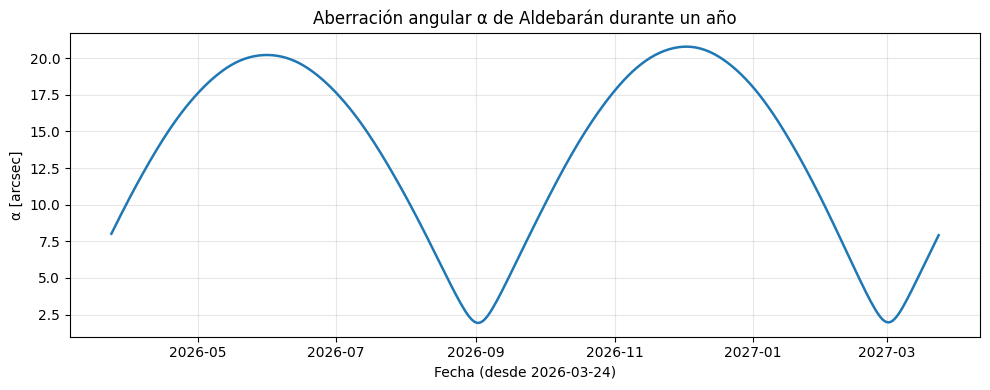

α mínimo = 1.934 arcsec
α máximo = 20.778 arcsec


In [47]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import date, timedelta
import pymcel as pc
import montu as mn
import spiceypy as spy

# Dirección de Aldebarán en coordenadas ecuatoriales J2000
allstars = mn.Stars()
star = allstars.get_stars(ProperName='Aldebaran')
ra = np.array(star.data.RAJ2000)[0]   # horas
dec = np.array(star.data.DecJ2000)[0] # grados

# Vector unitario de la estrella en sistema eclíptico J2000
deg = np.pi / 180
Requ2ecl = spy.pxform('J2000', 'ECLIPJ2000', 0)
nprima_equ = spy.latrec(1, ra * 15 * deg, dec * deg)
nprima_ecl = spy.mxv(Requ2ecl, nprima_equ)

# Intervalo temporal: un año a partir de hoy
inicio = date.today()
fin = inicio + timedelta(days=365)
epochs = {
    'start': inicio.strftime('%Y-%m-%d 00:00:00'),
    'stop': fin.strftime('%Y-%m-%d 00:00:00'),
    'step': '1d'
}

# Velocidad baricéntrica de la Tierra para cada fecha
tabla, jd, X = pc.consulta_horizons(id='399', location='@0', epochs=epochs)
X = np.asarray(X)
if X.ndim == 1:
    X = X.reshape(1, -1)
if X.shape[1] < 6 and X.shape[0] >= 6:
    X = X.T
v_tierra = X[:, 3:6]

# Aberración relativista por fecha
beta_vec = -v_tierra / pc.constantes.c
beta2 = np.sum(beta_vec**2, axis=1)
gamma = 1 / np.sqrt(1 - beta2)
dot = beta_vec @ nprima_ecl

n = (
    nprima_ecl
    + ((((gamma - 1) / beta2) * dot + gamma)[:, None] * beta_vec)
) / (gamma[:, None] * (1 + dot)[:, None])

cos_alpha = np.sum(n * nprima_ecl, axis=1) / np.linalg.norm(n, axis=1)
alpha_arcsec = np.degrees(np.arccos(np.clip(cos_alpha, -1, 1))) * 3600

# Fechas para el eje x
fechas = [inicio + timedelta(days=i) for i in range(len(alpha_arcsec))]

# Gráfico
plt.figure(figsize=(10, 4))
plt.plot(fechas, alpha_arcsec, lw=1.8)
plt.title('Aberración angular α de Aldebarán durante un año')
plt.xlabel(f'Fecha (desde {inicio.isoformat()})')
plt.ylabel('α [arcsec]')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'α mínimo = {alpha_arcsec.min():.3f} arcsec')
print(f'α máximo = {alpha_arcsec.max():.3f} arcsec')